<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center">
    <b style="font-size:3vw; color:#808080; font-weight:bold;">
    <center>S H A G G Y</center>
    </b>
</p>
<hr style="color:#808080;">

A demonstration notebook for our library **Shaggy** on CIFAR-10 dataset.


In [ ]:
import matplotlib.pyplot as plt
import torch

from IPython.display import clear_output
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

from shaggy.loss import AELoss
from shaggy.models.cae import create_ConvAE
from shaggy.optimizer import SOAP

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<hr style="color:#808080;">
<p align="center">
    <b style="font-size:2vw; color:#808080; font-weight:bold;">
    <center>D A T A S E T</center>
    </b>
</p>
<hr style="color:#808080;">


In [ ]:
# Load CIFAR-10 datasets
train_dataset, test_dataset = (
    datasets.CIFAR10(root="data", train=True, download=True, transform=transforms.ToTensor()),
    datasets.CIFAR10(root="data", train=False, download=True, transform=transforms.ToTensor()),
)

# Visualization of some samples from the test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=1)
samples, labels = next(iter(test_loader))
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for ax, img in zip(axes.flat, samples):
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
plt.tight_layout()
plt.show()

<hr style="color:#808080;">
<p align="center">
    <b style="font-size:2vw; color:#808080; font-weight:bold;">
    <center>C O N F I G U R A T I O N</center>
    </b>
</p>
<hr style="color:#808080;">


In [ ]:
config = {
    "in_channels": 3,
    "out_channels": 3,
    "lat_channels": 4,
    "hid_channels": [32, 16, 8],
    "hid_blocks": [3, 3, 3],
    "kernel_size": 3,
    "stride": 2,
    "pixel_shuffle": True,
    "ffn_factor": 1,
    "spatial": 2,
    "patch_size": 1,
    "periodic": False,
    "dropout": None,
    "checkpointing": False,
    "identity_init": True,
    "saturation": "softclip2",
    "saturation_bound": 5.0,
    "noise_level": 0.0,
}

config_training = {
    "lr": 1e-3,
    "epochs": 5,
    "batch_size": 128,
}

In [42]:
# Build model, loss, and optimizer.
model = create_ConvAE(**config).to(device)
loss_fn = AELoss().to(device)
optimizer = SOAP(model.parameters(), lr=config_training["lr"])

# Build train and test loaders.
train_loader = DataLoader(
    train_dataset,
    batch_size=config_training["batch_size"],
    shuffle=True,
    num_workers=1,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config_training["batch_size"],
    shuffle=False,
    num_workers=1,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters   : {n_params:,}")

Parameters   : 194,471


<hr style="color:#808080;">
<p align="center">
    <b style="font-size:2vw; color:#808080; font-weight:bold;">
    <center>T R A I N I N G</center>
    </b>
</p>
<hr style="color:#808080;">


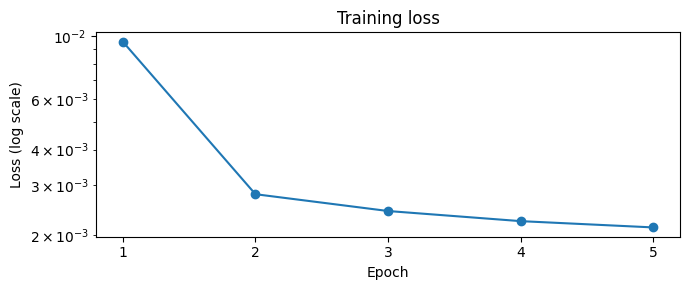

In [43]:
# Stores the average loss at each epoch for visualization.
losses = []

for epoch in range(1, config_training["epochs"] + 1):
    # Iterate over batches and show the per-batch loss live in the progress bar.
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{config_training['epochs']}", leave=False)
    model.train()
    total_loss = 0.0

    for batch, _ in pbar:
        # Forward pass.
        batch = batch.to(device)
        _, x_hat = model(batch)
        loss = loss_fn(x_hat, batch)

        # Backward pass.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss and refresh progress bar.
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # --- logging ---
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    # Redraw the loss curve after each epoch.
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(range(1, epoch + 1), losses, marker="o", linewidth=1.5)
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title("Training loss")

    plt.tight_layout()
    plt.show()

<hr style="color:#808080;">
<p align="center">
    <b style="font-size:2vw; color:#808080; font-weight:bold;">
    <center>D I A G N O S T I C S</center>
    </b>
</p>
<hr style="color:#808080;">


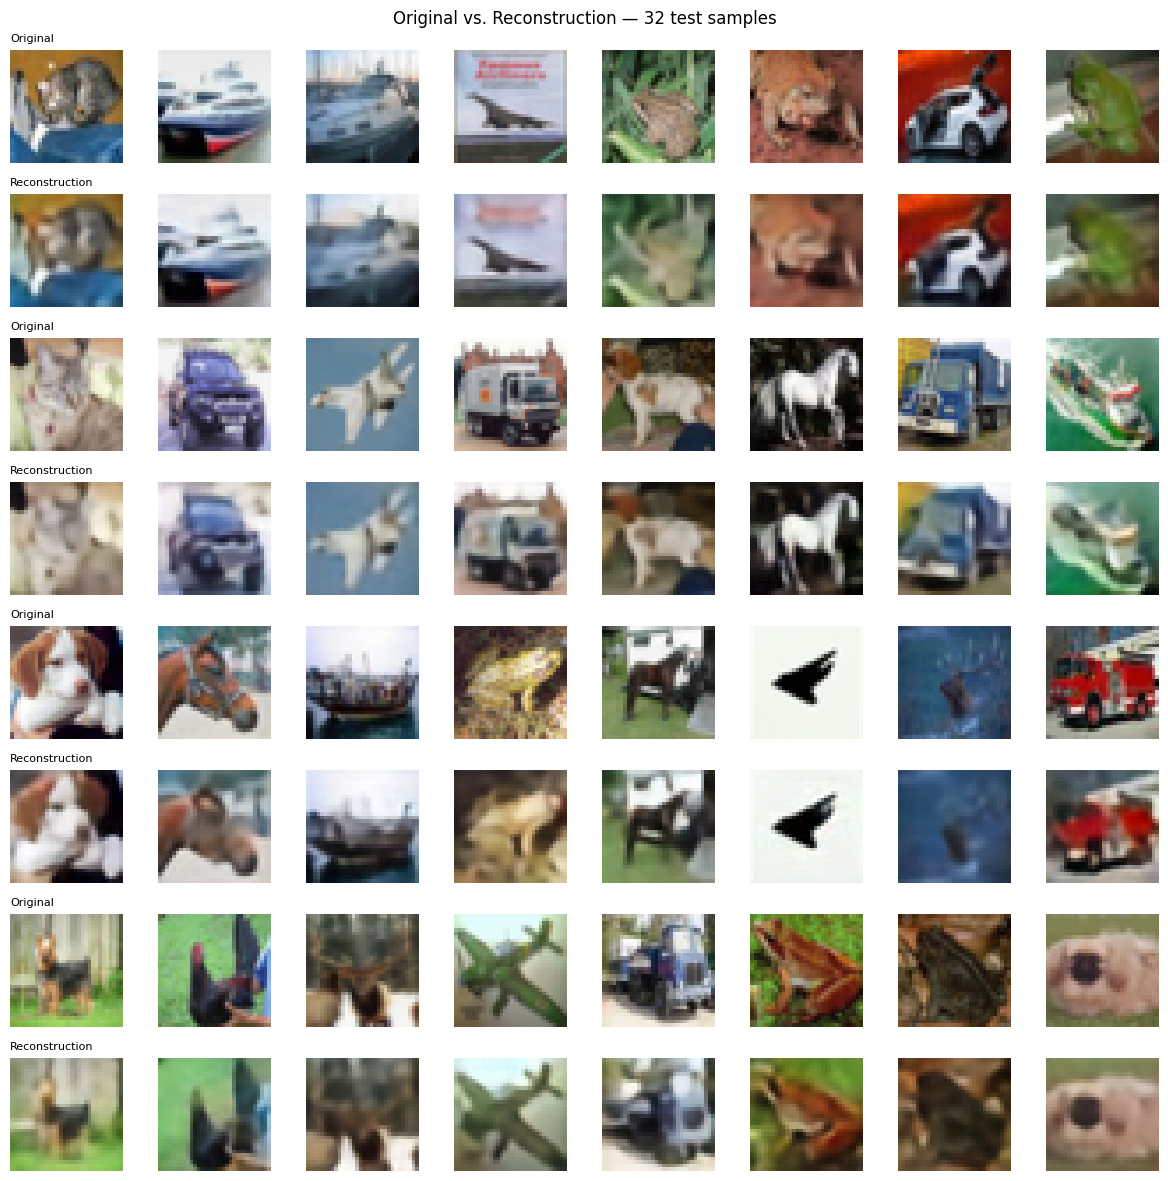

In [44]:
# Put the model in evaluation mode for inference.
model.eval()

# Constants for visualization.
N_COLS = 8
N_GROUPS = 4
N_SAMPLES = N_COLS * N_GROUPS

# Run one batch through the model without tracking gradients.
with torch.no_grad():
    originals, _ = next(iter(test_loader))
    originals = originals[:N_SAMPLES].to(device)
    _, reconstructions = model(originals)

# Move to CPU and reorder to (B, H, W, C) for matplotlib.
originals = originals.cpu().permute(0, 2, 3, 1)
reconstructions = reconstructions.cpu().clamp(0, 1).permute(0, 2, 3, 1)

# Display as N_GROUPS pairs of rows.
fig, axes = plt.subplots(N_GROUPS * 2, N_COLS, figsize=(N_COLS * 1.5, N_GROUPS * 3))

for group in range(N_GROUPS):
    row_orig = group * 2
    row_recon = group * 2 + 1

    for col in range(N_COLS):
        idx = group * N_COLS + col
        axes[row_orig, col].imshow(originals[idx])
        axes[row_recon, col].imshow(reconstructions[idx])
        axes[row_orig, col].axis("off")
        axes[row_recon, col].axis("off")

    axes[row_orig, 0].set_title("Original", loc="left", fontsize=8)
    axes[row_recon, 0].set_title("Reconstruction", loc="left", fontsize=8)

plt.suptitle(f"Original vs. Reconstruction — {N_SAMPLES} test samples")
plt.tight_layout()
plt.show()